In [1]:
import os
import sys
import matplotlib.pyplot as plt
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [2]:
import pandas as pd
import numpy as np
import src.features.seismic_features as sf

In [3]:
def process_real_catalog(dat_file):
    column_names = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'Latitude', 'Longitude', 'Depth', 'Magnitude']
    df = pd.read_csv(dat_file, header=None, names=column_names, sep='\s+')
    print(df)
    data_input = df.to_numpy()
    year = data_input[:, 0].astype(int)
    month = data_input[:, 1].astype(int)
    day = data_input[:, 2].astype(int)
    hour = data_input[:, 3].astype(int)
    minute = data_input[:, 4].astype(int)
    second = data_input[:, 5]

    data = np.column_stack((year, month, day, hour, minute, second))
    jd0 = sf.cal2jd([1970, 1, 1, 0, 0, 0])
    jd = np.array([sf.cal2jd(d) - jd0 for d in data])

    df.loc[:, 't'] = jd
    df['dt'] = df['t'].diff().shift(-1)
    df = df[['t', 'Magnitude', 'Latitude', 'Longitude', 'Depth', 'dt']]
    csv_file = os.path.splitext(dat_file)[0] + '.csv'
    df.to_csv(csv_file, index=False)
    return df


In [4]:
base_dir = os.path.join(project_root,'data', 'CD2')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
print(dat_files)
df1 = process_real_catalog(os.path.join(base_dir, 'raw', dat_files[0]))

['Chuandian2.dat']
         Year  Month  Day  Hour  Minute  Second  Latitude  Longitude  Depth  \
0        1970      1    1    12      55   16.00    26.050    100.980      0   
1        1970      1    2     6      14   14.60    38.100    119.470     26   
2        1970      1    2    10      56    0.00    37.200    114.830     17   
3        1970      1    2    13      45    5.00    40.300     77.000      0   
4        1970      1    2    18      56    0.00    35.700    122.500      0   
...       ...    ...  ...   ...     ...     ...       ...        ...    ...   
1495637  2023      8   13    23      17   37.45    37.922    115.216     12   
1495638  2023      8   13    23      27   38.85    37.916    115.246     26   
1495639  2023      8   13    23      29   35.34    24.327    101.880     15   
1495640  2023      8   13    23      29   59.71    23.850    114.501      9   
1495641  2023      8   13    23      49   13.80    29.726    106.016     13   

         Magnitude  
0          

In [5]:
base_dir = os.path.join(project_root,'data', 'CD2021')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
print(dat_files)
df4 = process_real_catalog(os.path.join(base_dir, 'raw', dat_files[0]))

['Chuandian2021.dat']
         Year  Month  Day  Hour  Minute  Second  Latitude  Longitude  Depth  \
0        1970      1    1    12      55   16.00    26.050    100.980      0   
1        1970      1    2     6      14   14.60    38.100    119.470     26   
2        1970      1    2    10      56    0.00    37.200    114.830     17   
3        1970      1    2    13      45    5.00    40.300     77.000      0   
4        1970      1    2    18      56    0.00    35.700    122.500      0   
...       ...    ...  ...   ...     ...     ...       ...        ...    ...   
1495637  2023      8   13    23      17   37.45    37.922    115.216     12   
1495638  2023      8   13    23      27   38.85    37.916    115.246     26   
1495639  2023      8   13    23      29   35.34    24.327    101.880     15   
1495640  2023      8   13    23      29   59.71    23.850    114.501      9   
1495641  2023      8   13    23      49   13.80    29.726    106.016     13   

         Magnitude  
0       

In [88]:
print(df1)

                    t  Magnitude  Latitude  Longitude  Depth        dt
0            0.538380        2.7    26.050    100.980      0  0.721512
1            1.259891        3.2    38.100    119.470     26  0.195664
2            1.455556        2.3    37.200    114.830     17  0.117419
3            1.572975        2.8    40.300     77.000      0  0.215914
4            1.788889        3.5    35.700    122.500      0  0.064444
...               ...        ...       ...        ...    ...       ...
1495637  19582.970572        2.2    37.922    115.216     12  0.006961
1495638  19582.977533        1.3    37.916    115.246     26  0.001348
1495639  19582.978881        1.2    24.327    101.880     15  0.000282
1495640  19582.979163        0.5    23.850    114.501      9  0.013358
1495641  19582.992521        2.4    29.726    106.016     13       NaN

[1495642 rows x 6 columns]


In [6]:
are_equal = df1.equals(df4)
print("df1 and df4 are identical:" , are_equal)

df1 and df4 are identical: True


In [91]:
def process_synthetic_catlog(dat_file):
    column_names =["ID1", "ID2", "t", "Magnitude", "Depth", "Longitude", "Latitude"]
    df = pd.read_csv(dat_file, header=None, names=column_names, sep='\s+')
    df['dt'] = df['t'].diff().shift(-1)
    df = df[['t', 'Magnitude', 'Latitude', 'Longitude', 'Depth', 'dt']]
    # 保存为同名csv文件
    csv_file = os.path.splitext(dat_file)[0] + '.csv'
    df.to_csv(csv_file, index=False)
    
    return df

In [92]:
base_dir = os.path.join(project_root,'data', 'S1')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
df2 = process_synthetic_catlog(os.path.join(base_dir, 'raw', dat_files[0]))

In [93]:
print(df2)

               t  Magnitude  Latitude  Longitude   Depth      dt
0        708.562      4.753    29.196    102.273     0.0  10.578
1        719.140      4.754    29.277    102.278     0.0  27.101
2        746.241      5.012    29.169    102.272     0.0  11.272
3        757.513      4.754    29.277    102.278     0.0  12.913
4        770.426      4.754    29.169    102.272     0.0   9.094
...          ...        ...       ...        ...     ...     ...
48801  19999.500      4.717    26.579    103.007 -3000.0   0.200
48802  19999.700      4.742    26.500    103.030     0.0   0.100
48803  19999.800      4.750    25.590    103.248     0.0   0.100
48804  19999.900      4.716    27.686    102.892 -3000.0   0.500
48805  20000.400      4.747    27.232    102.616     0.0     NaN

[48806 rows x 6 columns]


In [77]:
base_dir = os.path.join(project_root,'data', 'S2')
dat_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.dat')]
df3 = process_synthetic_catlog(os.path.join(base_dir, 'raw', dat_files[0]))

In [78]:
print(df3)

                t  Magnitude  Latitude  Longitude    Depth     dt
0         115.046      4.720    29.277    102.278 -18000.0  6.213
1         121.259      4.720    29.277    102.278 -18000.0  6.212
2         127.471      4.720    29.277    102.278 -18000.0  6.213
3         133.684      4.720    29.277    102.278 -18000.0  3.933
4         137.617      4.720    29.277    102.278 -15000.0  1.675
...           ...        ...       ...        ...      ...    ...
172841  19999.700      4.969    27.938    102.232  -6000.0  0.200
172842  19999.900      4.712    23.637    102.966 -18000.0  0.000
172843  19999.900      4.704    27.140    102.680 -18000.0  0.100
172844  20000.000      4.699    24.323    103.117 -18000.0  0.300
172845  20000.300      5.228    26.920    102.832 -18000.0    NaN

[172846 rows x 6 columns]


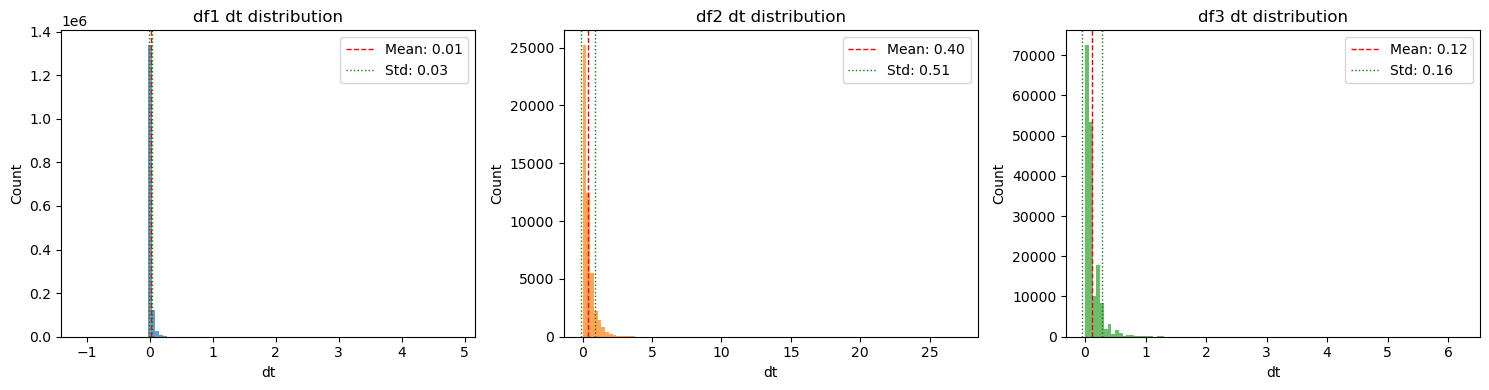

In [79]:
plt.figure(figsize=(15, 4))

for i, (df, name) in enumerate(zip([df1, df2, df3], ['df1', 'df2', 'df3'])):
    plt.subplot(1, 3, i+1)
    dt = df['dt'].dropna()
    plt.hist(dt, bins=100, alpha=0.7, color='C'+str(i))
    mean = dt.mean()
    std = dt.std()
    plt.axvline(mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean:.2f}')
    plt.axvline(mean + std, color='green', linestyle='dotted', linewidth=1, label=f'Std: {std:.2f}')
    plt.axvline(mean - std, color='green', linestyle='dotted', linewidth=1)
    plt.title(f'{name} dt distribution')
    plt.xlabel('dt')
    plt.ylabel('Count')
    plt.legend()

plt.tight_layout()
plt.show()

In [80]:
def load_and_filter_catalog(base_dir, Mc):
    csv_files = [f for f in os.listdir(os.path.join(base_dir, 'raw')) if f.endswith('.csv')]
    print(csv_files)
    if len(csv_files) != 1:
        raise ValueError(f"Expected exactly one csv file, but found {len(csv_files)}: {csv_files}")
    df = pd.read_csv(os.path.join(base_dir, 'raw', csv_files[0]))
    df = df[df['Magnitude'] >= Mc]
    df = df.reset_index(drop=True) # 重置索引
    return df

In [81]:
df = load_and_filter_catalog(base_dir, Mc=5.0)
print(df)

['size_3k_stress_0.6_dyn_0.8_mm_5.5_dm_0.5_b_0.4_yr_20k_EQ.csv']
               t  Magnitude  Latitude  Longitude    Depth     dt
0        250.967      5.514    23.252    102.825      0.0  0.620
1        252.727      5.127    29.250    102.276 -18000.0  1.247
2        264.206      5.115    23.278    102.834 -18000.0  0.317
3        268.577      5.128    29.277    102.278 -18000.0  0.137
4        271.264      5.259    29.250    102.276 -18000.0  0.040
...          ...        ...       ...        ...      ...    ...
23656  19994.300      5.259    24.512    103.132  -6000.0  0.100
23657  19995.500      5.121    23.919    103.070 -18000.0  0.100
23658  19997.300      5.120    23.304    102.844 -18000.0  0.000
23659  19998.900      5.239    26.448    103.046 -18000.0  0.000
23660  20000.300      5.228    26.920    102.832 -18000.0    NaN

[23661 rows x 6 columns]
